# Глубинное обучение, ИИ ВШЭ

## Домашнее задание 4. RNN.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [ ]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (2/3 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [ ]:
!pip install sentencepiece

In [105]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel
from train import train
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [106]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

In [ ]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (7/3 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью.

In [ ]:
model = LanguageModel(train_set)

In [ ]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (4/3 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится.

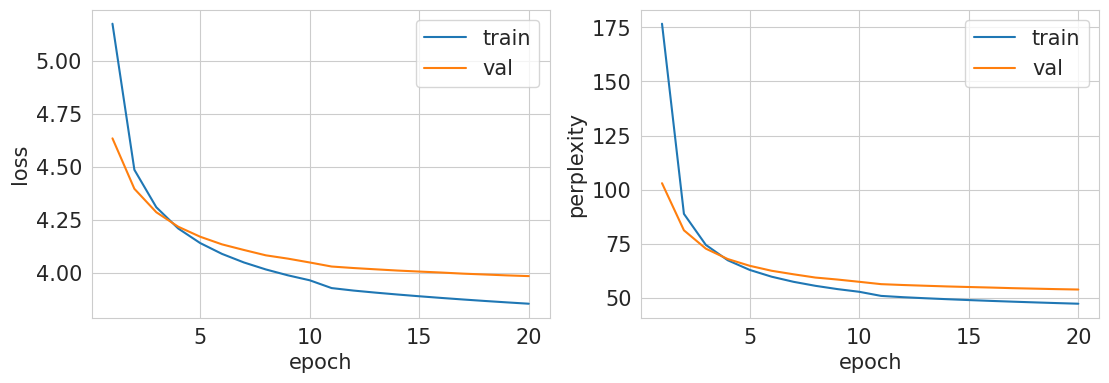

Generation examples:
 - а надо наш го с ду ра ди , а вот он за ком пом 


In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
num_workers = 1
num_epochs = 20

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)
val_loader = torch.utils.data.DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

model = LanguageModel(train_set).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, fused=True) # dont forget to set fused
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_dataloader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    num_examples=1
)

# Saving the model
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'checkpoint_rnn.pth')

## Задание 4: LSTM (1/3 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

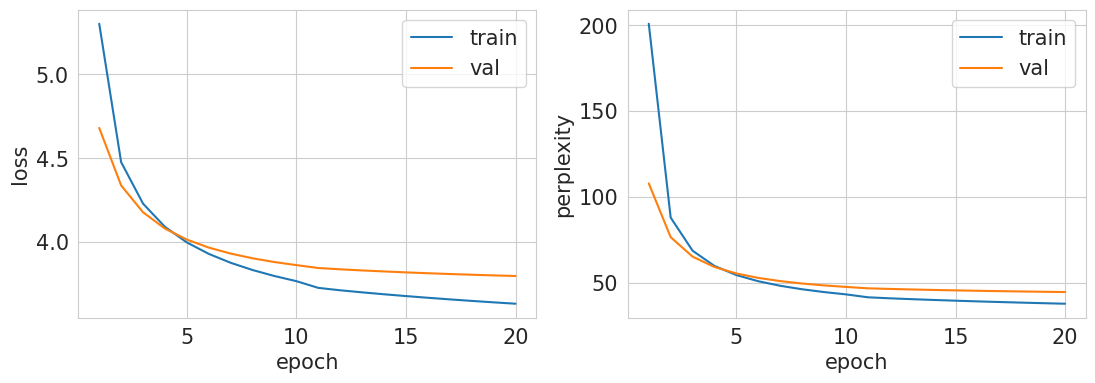

Generation examples:
 поло ма л двух именно о сло жи лся ру ками и евро со ю у прав лю . 


In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
num_workers = 1
num_epochs = 20

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)
val_loader = torch.utils.data.DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

model = LanguageModel(dataset=train_set, rnn_type=torch.nn.LSTM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, fused=True) # dont forget to set fused
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_dataloader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    num_examples=1
)

# Saving the model
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'checkpoint_lstm.pth')

`У LSTM немного более высокое качество и по лосссу и по перплексии чем у RNN. Но мне показалось, что несмотря на это, модель RNN чаще генирирует осмысленные части текста чем LSTM. При этом в этих осмысленных частях слова не всегда могут быть правильно написаны (иногда они разделены пробелом), но какой-то смысл в них увидеть всё равно можно.`

## Задание 5: Sampling temperature (1/3 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы.

In [ ]:
# Loading the model rnn
checkpoint = torch.load('checkpoint_rnn.pth', map_location=torch.device('cpu'))
model = LanguageModel(train_set)
model.load_state_dict(checkpoint['model_state_dict'])

In [ ]:
model.inference("Заходит мужик в бар", temp=0.7)

'Заходит мужик в бар су ди ла , что ли вы что - то все равно , что у тебя нет ! '

In [ ]:
# Loading the model lstm
checkpoint = torch.load('checkpoint_lstm.pth', map_location=torch.device('cpu'))
model = LanguageModel(train_set, rnn_type=torch.nn.LSTM)
model.load_state_dict(checkpoint['model_state_dict'])

In [ ]:
model.inference("Заходит мужик в бар", temp=0.7)

'Заходит мужик в бар и по фи цвет в ем ени , что щей с живо , а ля ра ст це , а сдела рии ени к не жен - ра мот . '

`При понижении температуры, генерации модели становятся более детерменированными, и можно прочитать больше полноценных слов. По качеству самих текстов модели RNN и LSTM примерно на одном уровне - в каких-то частях текста могут появляться реально существующие слова или же даже более менее осмысленные последовательности слов, но в целом текст больше похож на случайный набор символ, чем на какое-то осмысленное предложение.`

## Задание 5: Tokenizers (2/3 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [ ]:
train_set = TextDataset(
    data_file="jokes.txt",
    train=True,
    vocab_size=4000,
    sp_model_prefix="unigram",
    model_type="unigram"
)
valid_set = TextDataset(
    data_file="jokes.txt",
    train=False,
    vocab_size=4000,
    sp_model_prefix="unigram",
    model_type="unigram"
)

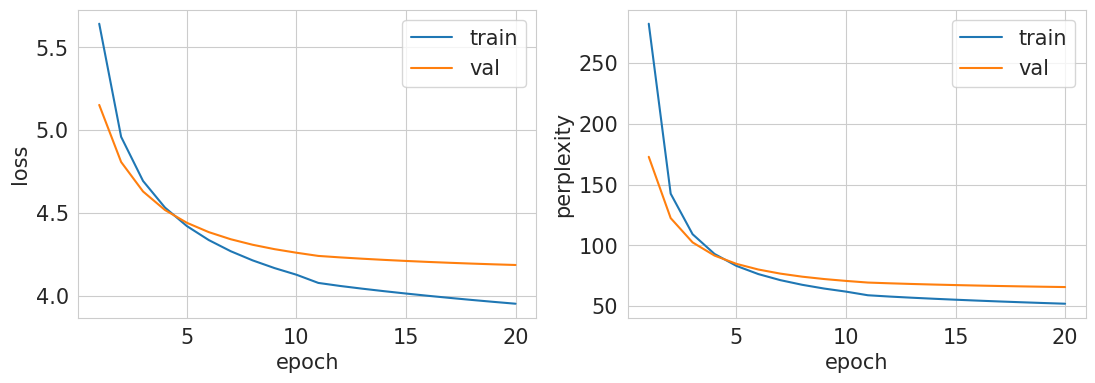

Generation examples:
 и ду к тра ге ва м с балкон а решили взять у него ду ши . 


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
num_workers = 1
num_epochs = 20

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)
val_loader = torch.utils.data.DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

model = LanguageModel(dataset=train_set, rnn_type=torch.nn.LSTM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, fused=True) # dont forget to set fused
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_dataloader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    num_examples=1
)

# Saving the model
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'checkpoint_lstm_unigram_4000.pth')

`Лосс и перплексию для моделей с разной токенизацией не совсем корректно сравнивать между собой, поскольку их значения зависят от размера словаря. Если сравнивать модели по качеству генерации, то можно заметить, что LSTM с unigram токенизацией генерирует больше полноценных слов, чем LSTM с BPE токенизацией (с меньшим числом токенов), но при этом текста обоих моделей всё еще больше похожи на случайный набор символов, чем на осмысленное предложение.`

## Задание 6. Latent Semantic Analysis (4/3 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [107]:
# bpe
train_set_bpe = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="bpe"
)
valid_set_bpe = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="bpe"
)
# unigram
train_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=True,
    vocab_size=4000,
    sp_model_prefix="unigram",
    model_type="unigram"
)
valid_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=False,
    vocab_size=4000,
    sp_model_prefix="unigram",
    model_type="unigram"
)

In [108]:
# Loading the model rnn bpe
checkpoint = torch.load('checkpoint_rnn.pth', map_location=torch.device('cpu'))
model_rnn_bpe = LanguageModel(train_set_bpe)
model_rnn_bpe.load_state_dict(checkpoint['model_state_dict'])
# Loading the model lstm bpe
checkpoint = torch.load('checkpoint_lstm.pth', map_location=torch.device('cpu'))
model_lstm_bpe = LanguageModel(train_set_bpe, rnn_type=torch.nn.LSTM)
model_lstm_bpe.load_state_dict(checkpoint['model_state_dict'])
# Loading the model lstm unigram
checkpoint = torch.load('checkpoint_lstm_unigram_4000.pth', map_location=torch.device('cpu'))
model_lstm_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM)
model_lstm_unigram.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [113]:
def get_text_vectors(model, dataset):
    # text
    generated_text = [model.inference("", 1) for _ in range(len(dataset))]
    validation_text = [dataset.ids2text(e[0]) for e in dataset]
    corpus = np.array(generated_text + validation_text)
    # tf-idf
    vectorizer = TfidfVectorizer()
    matrix = vectorizer.fit_transform(corpus)
    # svd
    svd = TruncatedSVD(random_state=42, n_components=100) # recomended 100 components for lsa (default 2 components)
    vectors = svd.fit_transform(matrix)
    generated_vectors = vectors[:len(valid_set_unigram),:]
    validation_vectors = vectors[len(valid_set_unigram):,:]
    return generated_vectors, validation_vectors

def mean_cosine_similarity(x, y):
    cosine_sim = cosine_similarity(x, y)
    max_cosine_sim = np.max(cosine_sim, axis=1)
    return max_cosine_sim.mean()

In [116]:
# text vectors
generated_text_rnn_bpe, validation_text_rnn_bpe = get_text_vectors(model_rnn_bpe, valid_set_bpe)
generated_text_lstm_bpe, validation_text_lstm_bpe = get_text_vectors(model_lstm_bpe, valid_set_bpe)
generated_text_lstm_unigram, validation_text_lstm_unigram = get_text_vectors(model_lstm_unigram, valid_set_unigram)

In [117]:
# mean similarity beetwen generated and validation text
print(f"rnn bpe: {mean_cosine_similarity(generated_text_rnn_bpe, validation_text_rnn_bpe)}")
print(f"lstm bpe: {mean_cosine_similarity(generated_text_lstm_bpe, validation_text_lstm_bpe)}")
print(f"lstm unigram: {mean_cosine_similarity(generated_text_lstm_unigram, validation_text_lstm_unigram)}")

rnn bpe: 0.5119267931375855
lstm bpe: 0.4798578165510486
lstm unigram: 0.5882106050870806


## Задание 7. Visualization (2/3 балла)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов.

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

## Задание 8. ruGPT perplexity (7/3 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.